# Testing models from https://iopscience.iop.org/article/10.1088/1361-6560/ad9133#pmbad9133app2

In [2]:
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from torch.utils.data import Dataset, DataLoader

import re
import os, fnmatch

import nibabel as nib

In [13]:
print(torch.version.cuda)

11.7


In [4]:
print('library uploaded, I am starting')

library uploaded, I am starting


In [5]:
from addl_models_bimodel_pytorch import VAE1_2, VAE_multimodel,VAE_1modality_PET

[NbConvertApp] Converting notebook addl_models_bimodel_pytorch.ipynb to script
[NbConvertApp] Writing 48447 bytes to addl_models_bimodel_pytorch.py


In [6]:
# folder for model and loss scores ONLY PET scans
#31_03_25 - beta KLD = 0.5, lr = 1e-5, latent feature size = 64, quantile norm + zscore norm, paralel decoders
#01_04_25 - beta KLD = 0, lr = 1e-5, latent feature size = 64, image sorting, no normalisation, paralel decoders
#02_04_25 - beta KLD = 0.1, lr = 1e-5, latent feature size = 64, image sorting, no normalisation, paralel decoders
#03_04_25 - beta KLD = 0.0001, lr = 1e-5, latent feature size = 64, image sorting, no normalisation, paralel decoders
#04_04_25 - beta KLD = 0.00001, lr = 1e-5, latent feature size = 64, image sorting, no normalisation, paralel decoders
#14_04_25 - rerun model from 01_04_25 with the fixed shaffled meta
#15_04_25 - rerun model from 04_04_25 with the fixed shaffled meta
#16_04_25 - model from 14_04_25, 0-1 normalisation
#01_05_25 - model from 14_04_25,  16 lat features, worse than 14_04_25
#02_05_25 - model from 14_04_25, 256 lat features
#03_05_25 -  model from 14_04_25, quantile + 0-1 normalisation, BCE loss and sigmoid activation function
#04_05_25 -  model from 14_04_25,lr = 1e-5 quantile + 0-1 normalisation, MSE loss and sigmoid activation function
#05_05_25 -  model from 14_04_25,lr = 1e-5 quantile + 0-1 normalisation, + 1 deconv layer
#06_05_25 -  model from 14_04_25,lr = 1e-5 quantile + 0-1 normalisation, more kernels, ReLU activation at the end of decoder
#07_05_25 -  model from 14_04_25,lr = 1e-5 quantile + 0-1 normalisation, + 1 deconv layer, ReLU activation at the end of decoder
#09_05_25 -  model from 14_04_25,lr = 1e-5 quantile + 0-1 normalisation, + 1 deconv layer, MSE loss, sigmoid activation, more kernels, leakurelu 
#10_05_25 -  NEW DEFAULT MODEL model from 14_04_25,lr = 1e-5 quantile + 0-1 normalisation, + 1 deconv layer, ReLU activation at the end of decoder, NO BATCH NORM
#23_05_25 -  model from 10_05_25, only siemens mri scans pairs
#25_05_25 -  model from 10_05_25, new PET-MRI pairs
#26_05_25 -  model from 10_05_25, new PET-MRI pairs,KLD = 0.00001 

#30_07_25 -  model from 10_05_25, new PET-MRI pairs,KLD = 0.00001, beta warm up  


date = '30_07_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

In [14]:
meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])
meta.reset_index(drop=True, inplace = True)
meta = meta.iloc[:,1:]

In [15]:
meta

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,Description,...,pet_90q,pet_95q,pet_99q,pet_999q,mri_min,mri_max,mri_90q,mri_95q,mri_99q,mri_999q
0,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,1/01/2016,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),...,1.276597,1.580674,1.978580,2.227910,0.0,933.950256,333.807138,400.404616,561.022889,715.850910
1,ADNI,ADNI 2,M,84.9,LMCI,v21,9/30/2013,69.7,PET,"AV45 Co-registered, Averaged <- PET Brain AV_4...",...,1.461337,1.827432,2.423643,3.054871,0.0,961.956360,261.757932,355.890277,548.642743,712.191625
2,ADNI,ADNI 2,M,75.7,CN,v21,1/22/2014,79.2,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",...,1.946882,2.580722,3.634248,4.486002,0.0,929.178406,240.742639,331.720949,514.238646,689.266167
3,A4,NaN,M,71.4,amyloidE,SCV2,1/01/2016,82.5,PET,Florbetapir <- PET Scan,...,1.602751,1.971324,2.412896,3.200057,0.0,2612.348389,1167.067993,1346.653394,1690.529869,2097.628151
4,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2016,71.8,PET,Florbetapir <- PET Scan,...,1.264202,1.570734,1.938521,2.115626,0.0,829.836975,333.076224,385.074081,572.254060,664.659743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3105,ADNI,ADNI 2,F,76.7,CN,v31,1/07/2015,78.9,PET,"AV45 Co-registered, Averaged <- AV45_Dyn_4x5mi...",...,1.242392,1.675523,2.288885,2.970504,0.0,795.983521,275.498734,457.167799,570.447152,660.795371
3106,ADNI,ADNI GO,M,65.3,CN,m48,12/15/2010,89.3,PET,"AV45 Co-registered, Averaged <- 20 min 3D AV45...",...,1.343642,1.698786,2.172019,2.475094,0.0,3832.770020,1110.165137,1252.057654,2077.359536,2712.287479
3107,ADNI,ADNI 2,M,72.1,AD,v21,9/20/2013,81.5,PET,"AV45 Co-registered, Averaged <- Adni AV45 4 X ...",...,1.674981,1.898488,2.122555,2.313443,0.0,2352.499023,1103.067615,1169.376953,1870.213466,2206.189639
3108,ADNI,ADNI 2,M,57.5,CN,v31,9/17/2014,79.1,PET,"AV45 Co-registered, Averaged <- ADNIGO - AV45 ...",...,1.327106,1.655667,2.027242,2.220455,0.0,1047.075317,297.941159,318.847514,457.731591,631.311213


In [9]:
meta.pet_99q.max()

4.548006567955016

In [10]:
np.quantile(meta.pet_max,0.99)

7.8971379470825225

<AxesSubplot:>

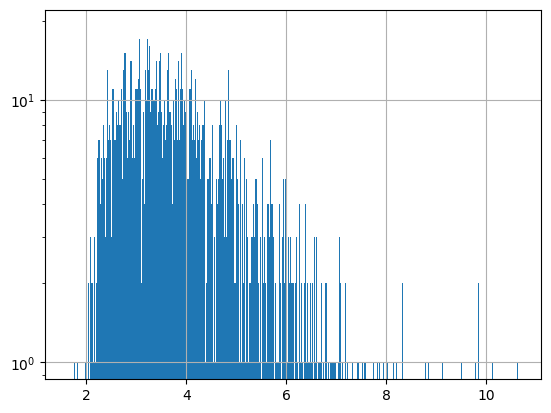

In [11]:
meta.pet_max.hist(bins = 1000, log = True)

<AxesSubplot:>

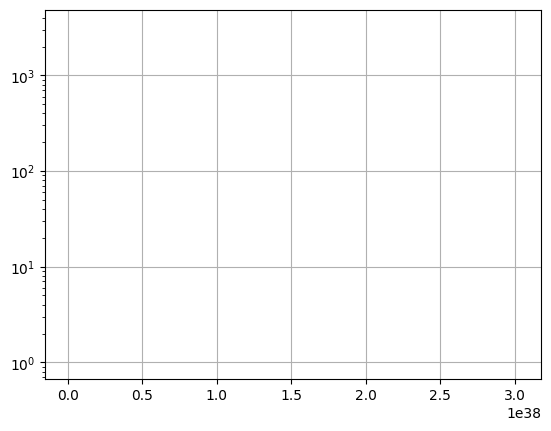

In [12]:
meta.mri_max.hist(bins = 1000, log = True)

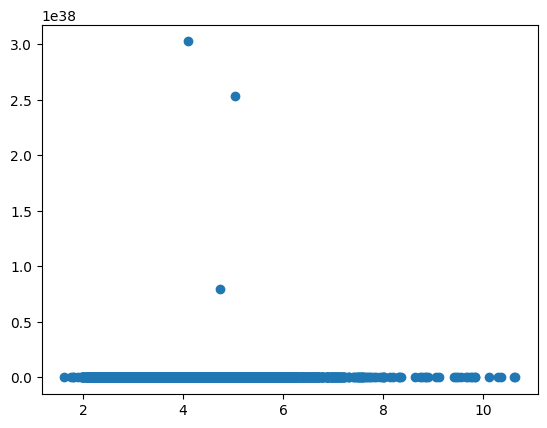

In [13]:
plt.scatter(meta.pet_max, meta.mri_max)

In [9]:
# why after quality control there is still empty scans? remove them 
meta = meta[meta.pet_max>0]

In [3]:
# Prep brain mask
brain_mask = nib.load('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz').get_fdata()
brain_mask[brain_mask != 0] = 1
#brain_mask = np.stack([brain_mask] * 2, axis=-1)

(-0.5, 217.5, 181.5, -0.5)

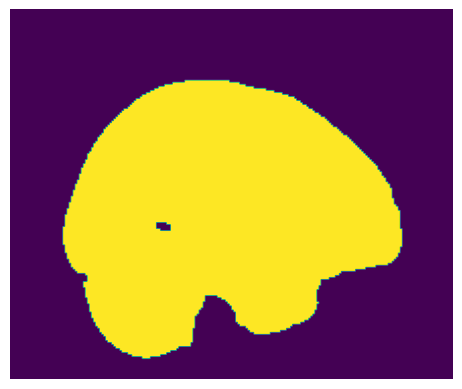

In [11]:
'''plt.imshow(np.rot90(brain_mask[60,:,:]))
plt.axis('off')'''

In [41]:
# already done in mri_processing script
# add path to pet scans normalised to whole cerebellum, script cerebellum_normalisation. 
'''for i in range(0,np.shape(meta)[0]):
    name_pet = meta['Image.Data.ID'][i]+'_normalised.nii'
    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/'), name_pet)
    if len(filename)> 0:
        meta.loc[i,'PET_PATH_normalised'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' + filename[0]
    
    name_mri = meta['MRI_ID'][i]+'_registered.nii'
    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_mri/'), name_mri)
    if len(filename)> 0:
        meta.loc[i,'MRI_PATH_registered'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_mri/' + filename[0]
     
    #print(i)'''

"for i in range(0,np.shape(meta)[0]):\n    name_pet = meta['Image.Data.ID'][i]+'_normalised.nii'\n    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/'), name_pet)\n    if len(filename)> 0:\n        meta.loc[i,'PET_PATH_normalised'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' + filename[0]\n    \n    name_mri = meta['MRI_ID'][i]+'_registered.nii'\n    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_mri/'), name_mri)\n    if len(filename)> 0:\n        meta.loc[i,'MRI_PATH_registered'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_mri/' + filename[0]\n     \n    #print(i)"

In [42]:
# already done in mri_processing script
# remove pet scans that failed registration&normalisation by some reasons. Why A4 registration failed?!
#meta2 = meta[meta['PATH_registered'].notna()]
'''meta2 = meta[meta['PET_PATH_normalised'].notna()]
meta2.reset_index(drop=True, inplace = True)'''

"meta2 = meta[meta['PET_PATH_normalised'].notna()]\nmeta2.reset_index(drop=True, inplace = True)"

In [43]:
# already done in mri_processing script
'''meta2 = meta2[meta2['MRI_PATH_registered'].notna()]
meta2.reset_index(drop=True, inplace = True)'''

"meta2 = meta2[meta2['MRI_PATH_registered'].notna()]\nmeta2.reset_index(drop=True, inplace = True)"

In [44]:
#shaffle

#meta2= meta.sample(frac=1, ignore_index = True)


In [45]:
# remove scans with bad registration, already done in mri processing script
'''meta_qc = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/registration/metafile_ADDLpipeline_abeta_mri_02_06_2024_afterQC.csv',header=[0], index_col=[0])
meta2 = meta
meta2 = meta2[meta2['Image.Data.ID'].isin(meta_qc['Image.Data.ID'])].copy()
meta2.reset_index(drop=True, inplace = True)'''

"meta_qc = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/registration/metafile_ADDLpipeline_abeta_mri_02_06_2024_afterQC.csv',header=[0], index_col=[0])\nmeta2 = meta\nmeta2 = meta2[meta2['Image.Data.ID'].isin(meta_qc['Image.Data.ID'])].copy()\nmeta2.reset_index(drop=True, inplace = True)"

In [11]:
#meta2 = meta[meta['MRI_Imaging.protocol'] == 'SIEMENS'].copy()
#meta2.reset_index(drop=True, inplace = True)
meta2 = meta.copy()
meta2.to_csv(path + '/metafile_shuffled_'+ date+'.csv')


In [12]:
meta2.shape

(942, 39)

In [49]:
stat = np.load("/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/stats_train.npz")
p_quant90 = stat['p_quant90']
m_quant90 = stat['m_quant90']

p_quant95 = stat['p_quant95']
m_quant95 = stat['m_quant95']

p_quant99 = stat['p_quant99']
m_quant99 = stat['m_quant99']

p_quant999 = stat['p_quant999']
m_quant999 = stat['m_quant999']

p_std = stat['p_std']
m_std = stat['m_std']

p_mean_clip = stat['p_mean_clip']
m_mean_clip = stat['m_mean_clip']
p_std_clip = stat['p_std_clip']
m_std_clip = stat['m_std_clip']

p_min_clip = stat['p_mim_clip']
m_min_clip = stat['m_min_clip']
p_max_clip = stat['p_max_clip']
m_max_clip = stat['m_max_clip']

In [50]:
print(stat.files)

['p_quant99', 'm_quant99', 'p_quant999', 'm_quant999', 'p_mean', 'm_mean', 'p_std', 'm_std', 'p_median', 'm_median', 'p_iqr', 'm_iqr', 'p_mean_clip', 'm_mean_clip', 'p_std_clip', 'm_std_clip', 'p_mim_clip', 'm_min_clip', 'p_max_clip', 'm_max_clip']


In [51]:
stat['p_quant99']

array(2.1990006)

In [52]:
stat['p_std_clip']

array(0.60700436)

In [53]:
# already done in mri_processing script
'''meta2['pet_min'] = 0
meta2['pet_max'] = 0
meta2['mri_min'] = 0
meta2['mri_max'] = 0
for i in range(meta2.shape[0]):
    img_pet = nib.load(meta2['PET_PATH_normalised'][i])
        
    img_mri = nib.load(meta2['MRI_PATH_registered'][i])
    
    image_pet = np.asarray(img_pet.get_fdata())
    image_mri = np.asarray(img_mri.get_fdata())
    
    meta2.loc[i,'pet_min'] = np.min(image_pet)
    meta2.loc[i,'pet_max'] = np.max(image_pet)
    
    meta2.loc[i,'mri_min'] = np.min(image_mri)
    meta2.loc[i,'mri_max'] = np.max(image_mri)
    
    print(i)
    
    
pet_minimum = np.min(meta2['pet_min'])
pet_maximum = np.max(meta2['pet_max'])
mri_minimum = np.min(meta2['mri_min'])
mri_maximum = np.max(meta2['mri_max'])
print(f'MinMax computation is done! PET minimum is {pet_minimum}, PET maximum is {pet_maximum}. MRI minimum is {mri_minimum}, MRI maximum is {mri_maximum}')
'''

"meta2['pet_min'] = 0\nmeta2['pet_max'] = 0\nmeta2['mri_min'] = 0\nmeta2['mri_max'] = 0\nfor i in range(meta2.shape[0]):\n    img_pet = nib.load(meta2['PET_PATH_normalised'][i])\n        \n    img_mri = nib.load(meta2['MRI_PATH_registered'][i])\n    \n    image_pet = np.asarray(img_pet.get_fdata())\n    image_mri = np.asarray(img_mri.get_fdata())\n    \n    meta2.loc[i,'pet_min'] = np.min(image_pet)\n    meta2.loc[i,'pet_max'] = np.max(image_pet)\n    \n    meta2.loc[i,'mri_min'] = np.min(image_mri)\n    meta2.loc[i,'mri_max'] = np.max(image_mri)\n    \n    print(i)\n    \n    \npet_minimum = np.min(meta2['pet_min'])\npet_maximum = np.max(meta2['pet_max'])\nmri_minimum = np.min(meta2['mri_min'])\nmri_maximum = np.max(meta2['mri_max'])\nprint(f'MinMax computation is done! PET minimum is {pet_minimum}, PET maximum is {pet_maximum}. MRI minimum is {mri_minimum}, MRI maximum is {mri_maximum}')\n"

In [54]:
# already done in mri_processing script
'''meta2 = meta2[meta2.mri_min >= 0]
meta2.reset_index(drop=True, inplace = True)'''

'meta2 = meta2[meta2.mri_min >= 0]\nmeta2.reset_index(drop=True, inplace = True)'

In [60]:
meta2[meta2.Project == 'A4']

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Age,Modality,Description,Imaging.Protocol,...,PET_PATH_normalised,MRI_PATH_registered,pet_min,pet_max,pet_99q,pet_999q,mri_min,mri_max,mri_99q,mri_999q
0,A4,NaN,F,66.7,LEARN amyloidNE,SCV2,74.8,PET,Florbetapir <- LZAZ- (AC),NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,1.146941e-07,2.813150,1.782727,2.042877,0.000000,421.777039,260.570492,318.701288
1,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,2.915222,1.978580,2.227910,0.000000,931.921692,560.718152,715.341770
4,A4,NaN,M,71.4,amyloidE,SCV2,82.5,PET,Florbetapir <- PET Scan,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,5.326364,2.412896,3.200057,0.000000,2607.167969,1690.464196,2098.051724
5,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,71.8,PET,Florbetapir <- PET Scan,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,2.588048,1.938521,2.115626,0.000000,857.024841,572.389360,664.744612
8,A4,NaN,F,66.0,amyloidE,SCV2,69.7,PET,Florbetapir <- None Provided,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,3.996044,2.207059,2.363511,0.000000,710.235840,439.850222,514.336438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3225,A4,NaN,F,58.5,amyloidE,SCV2,73.2,PET,Florbetapir <- PET Brain,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,2.513224,1.882642,1.998331,0.046645,508.663147,321.281344,406.118958
3230,A4,NaN,M,74.6,amyloidE,SCV2,74.1,PET,Florbetapir <- PET Scan,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,3.643130,2.161732,2.381854,0.000000,1031.740479,553.571946,673.623828
3242,A4,NaN,M,86.0,amyloidE,SCV2,77.4,PET,Florbetapir <- 4 X 5 MIN AC BRAIN,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,3.250043,2.045093,2.187682,0.000000,9512.872070,4160.496196,5426.038611
3247,A4,NaN,M,87.1,LEARN amyloidNE,SCV2,69.3,PET,Florbetapir <- PET Scan,NaN,...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0.000000e+00,2.805564,2.179004,2.410440,0.000000,1033.066040,594.847362,688.357234


In [61]:
#plt.hist(meta2.mri_max, bins = 10);

In [62]:
#plt.hist(meta2.mri_min);

In [18]:
#split data on train and test subsets
train_size = 0.8
train_end = int(len(meta2)*train_size)

In [19]:
meta2.PET_PATH_normalised

0      /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
1      /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
2      /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
3      /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
4      /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
                             ...                        
937    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
938    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
939    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
940    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
941    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
Name: PET_PATH_normalised, Length: 942, dtype: object

In [19]:
data_train = meta2[:train_end]
data_test = meta2[train_end:]

In [20]:
# create dictionaries with info for generator
data_partition = dict()
#abeta_labels = dict()
#abeta_all = dict()

t = int(0.8*np.shape(data_train)[0]) #!!
v = int(0.2*np.shape(data_train)[0]) 
#DATADIR = r"/csc/epitkane/data/ADNI/AD_DL_03_11_2021/"

# check the path 
data_partition['train'] = meta2.loc[:t,:].reset_index(drop=True) #!!
data_partition['validation'] = meta2.loc[t+1:train_end,:].reset_index(drop=True) #!!
data_partition['test'] = meta2.loc[train_end+1:,:].reset_index(drop=True) #!!

data_partition['all'] = meta2.loc[:,:].reset_index(drop=True) #!!


In [23]:
data_partition['test'].shape

(621, 39)

In [66]:
# augmentation function
def aug_random(scan):
    # add different level of noise
    def aug_noise0(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0)
        return t1_noise
    def aug_noise5(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.05)
        return t1_noise
    def aug_noise10(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.1)
        return t1_noise
    def aug_noise15(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.15)
        return t1_noise
    def aug_noise20(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.2)
        return t1_noise
    def aug_noise25(scan):
        t1_noise = add_gaussian_noise(scan.copy(), sigma=0.25)
        return t1_noise
    # flip an image
    def aug_flipx(scan):# 0 - flip by x axis, 1 - y axis,2 - by z, but it's seems useless
        t1_flip = flip(scan.copy(), axis=0)
        return t1_flip
    def aug_flipy(scan):
        t1_flip = flip(scan.copy(), axis=1)
        return t1_flip
    fns = [aug_noise0,aug_noise5,aug_noise10,aug_noise15,aug_noise20,aug_noise25,aug_flipx,aug_flipy]
    return choice(fns)(scan)

In [67]:
#p_quant99 = np.quantile(meta2.pet_max, 0.99)
#m_quant99 = np.quantile(meta2.mri_max, 0.99)

In [87]:
class PETMRISliceDataset(Dataset):
    def __init__(self, list_IDs_pet, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant999,mri_quant = m_quant999, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        """
        PyTorch Dataset for paired 2D slices of PET and MRI scans.
        """
        self.list_IDs_pet = list_IDs_pet
        #self.list_IDs_mri = list_IDs_mri
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_pet):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        pet_slices = []
        pet_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            pet_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            pet_path = pet_path[0]
            if not isinstance(pet_path, str):  
                print(pet_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(pet_path)}")
                
        
        img_pet = nib.load(pet_path).get_fdata()
        #img_mri = nib.load(mri_path).get_fdata()

            # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            pet_slice = img_pet[slice_num_inimg, :, :]
            #mri_slice = img_mri[slice_num_inimg, :, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                pet_slice *= bm
                #mri_slice *= bm
                    
        elif self.slice_axis == 1:  # Coronal
            pet_slice = img_pet[:, slice_num_inimg, :]
            #mri_slice = img_mri[:, slice_num_inimg, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                pet_slice *= bm
                #mri_slice *= bm
            
        else:  # Axial (default)
            pet_slice = img_pet[:, :, slice_num_inimg]
            #mri_slice = img_mri[:, :, slice_num_inimg]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                pet_slice *= bm
                #mri_slice *= bm

            # Skip slices with NaNs or empty regions
        #if np.isnan(pet_slice).any() and np.isnan(mri_slice).any():
        #    return None, None, None, None 
        #if np.max(pet_slice) == 0 and np.max(mri_slice) == 0:
        #    return None, None, None, None 
            # Skip empty slices
            #if pet_slice.size == 0 or mri_slice.size == 0:
            #    continue  # Skip this slice

            # Normalize if necessary (optional step, currently not applied)
        
        pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant), self.pet_minimum, self.pet_maximum)
        #mri_norm = self.min_max_normalize(np.asarray(mri_slice, dtype=np.float32), float(self.mri_quant), self.mri_minimum, self.mri_maximum)
        
        pet_norm = np.clip(pet_norm, 1e-7, 1 - 1e-7) #???or just to 0 and 1?
            # Stack PET and MRI as channels
        #input_2ch = np.stack([pet_norm, mri_norm], axis=0)
            #print(input_2ch.shape) [2,100,200]

            #batch_data.append(input_2ch)  # Store the correct 2-channel data
        #pet_ids.append(pet_path)
        #mri_ids.append(mri_path)
            #print(f"pet_slice shape: {pet_slice.shape}, mri_slice shape: {mri_slice.shape}")

        # Convert to NumPy arrays
        
        batch_data = np.array(pet_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, pet_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        pet_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, pet_ids, slice_n = self.__data_generation([(pet_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)


        return { 'image': X, 'pet_ID': pet_ids, 'slice_number': slice_n }

    #def min_max_normalize(image, min_val, max_val):
    #    return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero

    def quantile_norm(self, image, quantile, mean, std):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        return image
    def min_max_normalize(self,image,quantile, min_val, max_val):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 0, quantile)  # Clip values above quantile
        return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero


In [88]:
# creating datasets 
train_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['train']['PET_PATH_normalised'], brain_mask = brain_mask)

validation_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['validation']['PET_PATH_normalised'], brain_mask = brain_mask)

test_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['test']['PET_PATH_normalised'], brain_mask = brain_mask)


In [89]:
# creating dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=64,
                        shuffle=False, num_workers=8)

validation_dataloader = DataLoader(validation_dataset, batch_size=64,
                        shuffle=False, num_workers=8)

test_dataloader = DataLoader(test_dataset, batch_size=64,
                        shuffle=False, num_workers=8)

In [90]:
train_dataset[0]['image'].shape

torch.Size([1, 182, 218])

In [91]:
train_dataset[0]['image'].max()

tensor(0.)

In [129]:
len(validation_dataloader.dataset) # number of slices

100282

In [130]:
len(validation_dataloader) # number of batches

1567

In [ ]:
'''for batch_idx, (data) in enumerate(train_dataloader):
    while batch_idx == 0:
        data = data['image']
        print(len(data))'''

In [133]:
#data.shape

torch.Size([64, 1, 182, 218])

In [ ]:
#plt.hist(data[:,1,:,:].flatten())

In [ ]:
'''plt.imshow(np.rot90(data[60,0,:,:]))
plt.axis('off')'''

In [ ]:
#plt.hist(data[:,0,:,:].flatten())

In [12]:
1e-5

1e-05

In [30]:
# compile the model 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") #"cuda:0" if torch.cuda.is_available() else "cpu"
#model = VAE1_2(64*64*64, latent_size =64,in_channels=2).to(device)
model = VAE_1modality_PET(64*64*64, latent_size =64,in_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
#optimizer = optim.SGD(model.parameters(), lr=1e-7)
#optimizer = adamod.AdaMod(model.parameters(), lr=1e-5, beta3=0.999)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)

#model = torch.utils.checkpoint.checkpoint_sequential(model)
#model.train()
#summary(CCVAE)

In [31]:
sum([param.nelement() for param in model.parameters()])

78953258

In [ ]:
#standart loss function
def loss_function(recon_x, x, mu, logvar,beta):
    #recon_loss = F.binary_cross_entropy(recon_x, x,reduction='sum')
    # Mask out the 0 regions
    #mask = (x != 0)  # Create a binary mask for non-zero values

    # Compute loss only for non-zero regions
    recon_loss = F.mse_loss(recon_x, x, reduction='mean') # mean of mse losses within batch 
    #recon_loss = F.binary_cross_entropy(recon_x, x, reduction='mean')
    #recon_loss = torch.mean(torch.mean((x - recon_x) ** 2, dim=(1, 2, 3)))
    #print('Reconstruction loss of the epoch:',recon_loss.mean().item())
    logvar = torch.clamp(logvar, max=5, min = -5)
    KLD = -0.00001 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim = 1) # or torch.mean()?
    #KLD = -1 * beta * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim = 1)
    
    #KLD = 0 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    #KLD = 1 * torch.mean(torch.sum(KLD, dim=0))
    #print('KLD loss of the epoch:',KLD.mean().item())
    return recon_loss,torch.mean(KLD)
   


In [ ]:
def beta_schedule(epoch, total_epochs, max_beta=0.1):
    return max_beta * (epoch / total_epochs)

def cyclic_beta_schedule(epoch, cycle_length=50, max_beta=0.001):
    cycle_pos = epoch % cycle_length
    return max_beta * (cycle_pos / (cycle_length - 1))

In [ ]:
total_epochs=1000 #!!!!!!!!!!!!!!change if needed !!!!!!!!!!

def train(epoch):
    #device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.train()
    train_loss = 0
    sample_n = 0
    for batch_idx, (data) in enumerate(train_dataloader):
        #cond = data['condition'].type(torch.FloatTensor).to(device)
        #print(data.shape)
        data = data['image'].type(torch.FloatTensor).to(device)
        #print(data[0].shape)
        #labels = one_hot(labels, 10)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        
        #beta = beta_schedule(epoch, total_epochs)
        beta = cyclic_beta_schedule(epoch)
        
        recon, kld = loss_function(recon_batch, data, mu, logvar,beta)
        loss = recon + kld
        
        #print("Mean mu:", mu.mean().item(), "Min:", mu.min().item(), "Max:", mu.max().item())

        #torch.save(mean, path+'/mu')
        #torch.save(var, path+'/logvar')
        #torch.save(data, path+'/x')
        #torch.save(recon_batch, path+'/recon_batch')
        #torch.save(recon_l, path+'/recon_loss')
        #print(logvar)
        #print(torch.max(logvar))
        #print(torch.min(logvar))
        #logvar = torch.clamp(logvar, max = 10.0) # limitation on logvar value ???
        
        #print(kld)
        #print(recon)
        #loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        #print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
        #print(f"Reserved memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")
    
        #nn.utils.clip_grad_norm_(model.parameters(), 1.0) # gradient clipping to escape gradient exploding
        train_loss += loss.detach().cpu().numpy()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTotal loss: {:.6f}\tReconstruction loss: {:.6f}  KL loss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_dataloader.dataset),
                100. * batch_idx / len(train_dataloader),
                loss.sum().item() ,
            recon.sum().item() ,
            kld.sum().item() ))
            print(beta)
            #print("Mean logvar:", logvar.mean().item(), "Min:", logvar.min().item(), "Max:", logvar.max().item())
    
            
        
        
    train_loss /= len(train_dataloader)
    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss))
    
    torch.cuda.empty_cache()
    return train_loss

In [ ]:
def validation(epoch):
    #device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    validation_loss = 0
    avg_reconstruction_loss = 0
    avg_kl_loss = 0
    total_reconstruction_loss = 0
    total_kl_loss = 0
    
    with torch.no_grad():
        for i, (data) in enumerate(validation_dataloader):
            #cond = data['condition'].type(torch.FloatTensor).to(device)
            data = data['image'].type(torch.FloatTensor).to(device)
            
            recon_batch, mu, logvar = model(data) #, cond
            #beta = beta_schedule(epoch, total_epochs)
            beta = cyclic_beta_schedule(epoch)
            recon, kld = loss_function(recon_batch, data, mu, logvar,beta)
            loss = recon + kld
            validation_loss += loss.detach().item()
            total_reconstruction_loss += recon.detach().item()
            total_kl_loss += kld.detach().item()
            
            '''if i == 0:
                n = min(data.size(0), 5)
                comparison = torch.cat([data[:n],
                                      recon_batch.view(-1, 1, 28, 28)[:n]])
                save_image(comparison.cpu(),
                         'reconstruction_' + str(f"{epoch:02}") + '.png', nrow=n)'''

    validation_loss /= len(validation_dataloader)
    avg_reconstruction_loss = total_reconstruction_loss / len(validation_dataloader)
    avg_kl_loss = total_kl_loss / len(validation_dataloader)
    
    print('====> Validation total loss: {:.4f}\tReconstruction loss: {:.6f}  KL loss: {:.6f}'.format(validation_loss,avg_reconstruction_loss,avg_kl_loss))
    
    
    
    return validation_loss



In [ ]:


'''def train(epoch):
    model.train()
    train_loss = 0
    
    for batch_idx, (batch_data) in enumerate(train_dataloader):
        x, _ = batch_data
        # Apply padding
        pad_pet = ImagePadding2D(x)  # Assuming ImagePadding2D is defined elsewhere
        padded_pet = pad_pet.pad_to_size((256, 256))

        # Forward pass
        z_mean, z_log_var, z = model.encoder(padded_pet)
        reconstruction = torch.cat([model.decoders[0](z), model.decoders[1](z)], dim=1)

        # Compute loss
        total_loss, reconstruction_loss, kl_loss = model.compute_loss(x, reconstruction, z_mean, z_log_var)
        
        # Zero the gradients
        optimizer.zero_grad()
        total_loss.backward()  # Backpropagation
        train_loss += total_loss.detach().cpu().numpy()
        
        optimizer.step()       # Update model parameters
        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTotal loss: {:.6f}\tReconstruction loss: {:.6f}\\KL loss: {:.6f}'.format(
                epoch, batch_idx * len(batch_data), len(train_dataloader.dataset),
                100. * batch_idx / len(train_dataloader),
                total_loss.sum().item() / len(batch_data),
            reconstruction_loss.sum().item() / len(batch_data),
            kl_loss.sum().item() / len(batch_data)))
            
        
    train_loss /= len(train_dataloader.dataset)
    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss))
    torch.cuda.empty_cache()
    return train_loss
'''

In [87]:
'''def validation(epoch):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()
    validation_loss = 0
    with torch.no_grad():
        for i, (batch_data) in enumerate(validation_dataloader):
            x, _ = batch_data

            pad_pet = ImagePadding2D(x)  # Assuming ImagePadding2D is defined elsewhere
            padded_pet = pad_pet.pad_to_size((256, 256))

            # Forward pass
            z_mean, z_log_var, z = model.encoder(padded_pet)
            reconstruction = torch.cat([model.decoders[0](z), model.decoders[1](z)], dim=1)

            # Compute loss
            total_loss_batch, reconstruction_loss_batch, kl_loss_batch = model.compute_loss(x, reconstruction, z_mean, z_log_var)

            # Accumulate the losses
            total_loss += total_loss_batch.detach().item()
            total_reconstruction_loss += reconstruction_loss_batch.detach().item()
            total_kl_loss += kl_loss_batch.detach().item()
            

    
    # Calculate average losses
    avg_total_loss = total_loss / len(validation_dataloader)
    avg_reconstruction_loss = total_reconstruction_loss / len(validation_dataloader)
    avg_kl_loss = total_kl_loss / len(validation_dataloader)
    
    
    print('====> Validation total loss: {:.4f}\tReconstruction loss: {:.6f}\\KL loss: {:.6f}'.format(avg_total_loss,avg_reconstruction_loss,avg_kl_loss))

    return avg_total_loss

'''

In [ ]:
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should return >0 if GPUs are available
print(torch.cuda.get_device_name(0))  # Should print the GPU name

In [1]:
print(torch.version.cuda)

NameError: name 'torch' is not defined

In [ ]:
print('model training starts now')

In [ ]:
epochs = 1000
early_stop_thresh = 10
best_epoch = 0
train_loss_list = []
val_loss_list = []
lr = []
i = 0
iterations = 5
while i < iterations:
    for epoch in range(0, epochs):

            train_loss = train(epoch)
            val_loss = validation(epoch)
            if np.isnan(val_loss) or np.isinf(val_loss):
                print('Validation loss - Nan, restart the loop :( ')
                i +=1
                break
                

            train_loss_list.append(train_loss)
            val_loss_list.append(val_loss)
            lr.append(optimizer.param_groups[0]["lr"])
            np.save(path + "/train_loss", np.array(train_loss_list))
            np.save(path +  "/val_loss", np.array(val_loss_list))
            np.save(path +  "/lr", np.array(lr))

            scheduler.step(val_loss) #!!!!!!!!!!!!!!!!!!!!

            if epoch == 0:
                best_loss = val_loss
                torch.save(model, path+"/best_model.pth")
            else:
                if val_loss < best_loss:
                    best_loss = val_loss
                    best_epoch = epoch
                    torch.save(model, path+"/best_model.pth")
                    #torch.save(model.state_dict(), path+"/best_model.pth")
                    #save_model(model, epoch)
                    #checkpoint(model, "best_model.pth")
                elif epoch - best_epoch >= early_stop_thresh:
                    i = iterations  # break while loop if model training was successful 
                    print("Early stopped training at epoch %d" % epoch)
                    break  # terminate the training loop
                    
    if epoch == epochs-1: # break while loop if model training was successful 
        break 


        

In [ ]:
print('Training is done!')